## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load DataSet

In [2]:
df = pd.read_csv("creditcard.csv")

## Preprocessing

In [3]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [4]:
df['Amount'] = scaler.fit_transform(df[['Amount']])
df = df.drop(['Time'], axis=1)

In [5]:
X = df.drop('Class', axis=1)
y = df['Class']

## Train Test Split

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Fraud vs Normal Transactions

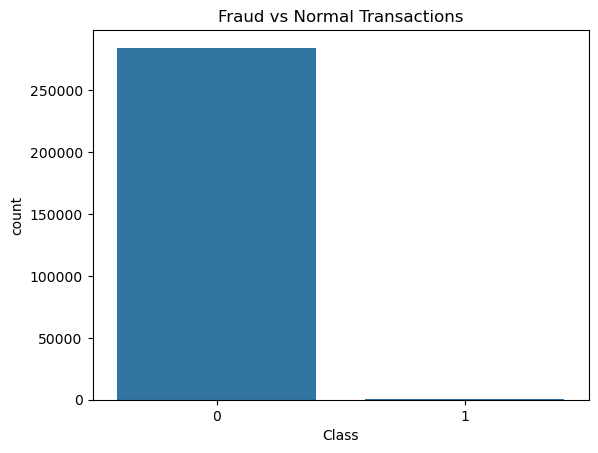

In [7]:
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

# Logistic Regression

In [10]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=100)

In [11]:
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Logistic Regression Results
Accuracy: 0.9990871107053826
[[56854    10]
 [   42    56]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.57      0.68        98

    accuracy                           1.00     56962
   macro avg       0.92      0.79      0.84     56962
weighted avg       1.00      1.00      1.00     56962



# DecisionTreeClassifier

In [14]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(max_depth=10)

In [15]:
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

print("\n=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Report:\n", classification_report(y_test, y_pred_dt))


=== Decision Tree ===
Accuracy: 0.999403110845827
F1 Score: 0.8172043010752689
Confusion Matrix:
 [[56852    12]
 [   22    76]]
Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.78      0.82        98

    accuracy                           1.00     56962
   macro avg       0.93      0.89      0.91     56962
weighted avg       1.00      1.00      1.00     56962



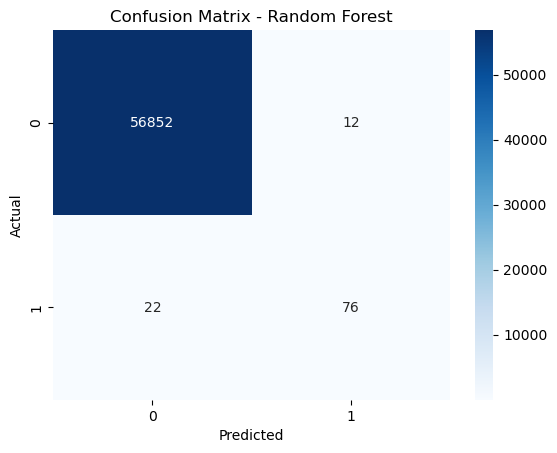

In [17]:
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()